In [1]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import featuretools as ft

In [2]:
# Load datasets and limit to the first 1000 rows
app_train = pd.read_csv('data/application_train.csv').sort_values('SK_ID_CURR').reset_index(drop=True).loc[:999, :]
app_test = pd.read_csv('data/application_test.csv').sort_values('SK_ID_CURR').reset_index(drop=True).loc[:999, :]
bureau = pd.read_csv('data/bureau.csv').sort_values(['SK_ID_CURR', 'SK_ID_BUREAU']).reset_index(drop=True).loc[:999, :]
bureau_balance = pd.read_csv('data/bureau_balance.csv').sort_values('SK_ID_BUREAU').reset_index(drop=True).loc[:999, :]
cash = pd.read_csv('data/POS_CASH_balance.csv').sort_values(['SK_ID_CURR', 'SK_ID_PREV']).reset_index(drop=True).loc[:999, :]
credit = pd.read_csv('data/credit_card_balance.csv').sort_values(['SK_ID_CURR', 'SK_ID_PREV']).reset_index(drop=True).loc[:999, :]
previous = pd.read_csv('data/previous_application.csv').sort_values(['SK_ID_CURR', 'SK_ID_PREV']).reset_index(drop=True).loc[:999, :]
installments = pd.read_csv('data/installments_payments.csv').sort_values(['SK_ID_CURR', 'SK_ID_PREV']).reset_index(drop=True).loc[:999, :]

In [ ]:
es = ft.EntitySet(id="client_data")
es = es.add_dataframe(dataframe_name="app_train",
                      dataframe=app_train,
                      index="SK_ID_CURR")

es = es.add_dataframe(dataframe_name="bureau",
                      dataframe=bureau,
                      index="SK_ID_BUREAU")
es = es.add_dataframe(dataframe_name="previous",
                      dataframe=previous,
                      index="SK_ID_PREV")
print(es)



c:\Users\gamer\miniconda3\envs\Atari_Gym\lib\site-packages\woodwork\type_sys\utils.py:40: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(
c:\Users\gamer\miniconda3\envs\Atari_Gym\lib\site-packages\woodwork\type_sys\utils.py:40: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(
c:\Users\gamer\miniconda3\envs\Atari_Gym\lib\site-packages\woodwork\type_sys\utils.py:40: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(
c:\Users\gamer\miniconda3\envs\Atari_Gym\lib\site-packages\woodwork\type_sys\utils.py:40: UserWarning: Could not infer forma

Entityset: client_data
  DataFrames:
    app_train [Rows: 1000, Columns: 250]
    bureau [Rows: 1000, Columns: 17]
    previous [Rows: 1000, Columns: 37]
  Relationships:
    No relationships


c:\Users\gamer\miniconda3\envs\Atari_Gym\lib\site-packages\woodwork\type_sys\utils.py:40: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(
c:\Users\gamer\miniconda3\envs\Atari_Gym\lib\site-packages\woodwork\type_sys\utils.py:40: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(


Entityset: client_data
  DataFrames:
    app_train [Rows: 1000, Columns: 250]
    bureau [Rows: 1000, Columns: 17]
    previous [Rows: 1000, Columns: 37]
  Relationships:
    No relationships
Entityset: client_data
  DataFrames:
    app_train [Rows: 1000, Columns: 250]
    bureau [Rows: 1000, Columns: 17]
    previous [Rows: 1000, Columns: 37]
  Relationships:
    bureau.SK_ID_CURR -> app_train.SK_ID_CURR


c:\Users\gamer\miniconda3\envs\Atari_Gym\lib\site-packages\featuretools\entityset\entityset.py:414: UserWarning: Logical type Integer for child column SK_ID_CURR does not match parent column SK_ID_CURR logical type Double. Changing child logical type to match parent.
  warnings.warn(


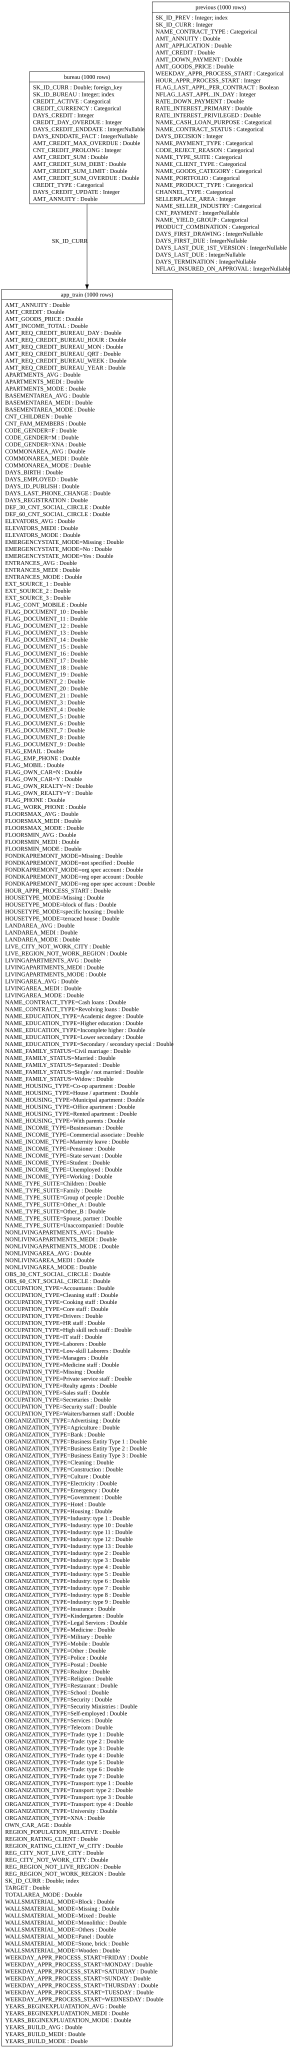

: 

In [ ]:
print(es)
#add a relationship between app_train and bureau

es.add_relationship(parent_dataframe_name="app_train",
    parent_column_name="SK_ID_CURR",
    child_dataframe_name="bureau",
    child_column_name="SK_ID_CURR")
print(es)

# Visualize the entity graph
es.plot()

In [17]:
print(ft.__version__)

1.28.0
